# Regresión con Procesos Gaussianos

En este notebook vamos a introducir las regresiones de funciones con procesos Gaussianos.

### Importación de paquetes necesarios

In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF # funcion kernel de cov(t, t')
from typing import Callable
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

### Definición de las variables globales

In [3]:
TIME_VAL_MIN = 0
TIME_VAL_MAX = 7
PREDICTORS = np.array([0.5, 1.3, 1.4, 2.7, 3.5, 4.2, 5.8, 6.7]).reshape(-1,1)

### Definición de las funciones

In [10]:
def linspace_time(min_val: float, max_val: float, N: int= 50) -> np.ndarray: 
    """
    Genera un array de valores de tiempo espaciados de manera uniforme.
    
    Args:
        min_val (float): Valor mínimo del array.
        max_val (float): Valor máximo del array.
        N (int,optional): Cantidad de valores del array. Default: 50.
        
    Returns:
        np.ndarray: Array de valores de tiempo.
    """
    return np.linspace(min_val, max_val, N).reshape(-1, 1)


def evaluate_function(t: float) -> float:
    """
    Evalúa la función f(t) = t(10 - t) + sin(2πt).

    Args:
        t (float): Variable de entrada.

    Returns:
        float: Valor de la función evaluada en t.
    """
    return t * (10 - t) + np.sin(t * 2 * np.pi)


def generate_obs(
    t_train: np.ndarray,
    scale_val: float = 0.1,
    func: Callable[[np.ndarray], np.ndarray] = evaluate_function
) -> np.ndarray:
    """
    Genera un observable agregando ruido a una función.

    Args:
        t_train (np.ndarray): Valor predictor de entrada.
        scale_val (float, optional): Desviación estándar del ruido.Default: 0.1.
        func (Callable[[np.ndarray], np.ndarray],optional): Función a evaluar. 
            Default: evaluate_function.

    Returns:
        np.ndarray: Valor de la función con ruido añadido.
    """
    return func(t_train) + np.random.normal(scale=scale_val, size=np.shape(t_train))


def gaus_proc_regressor(
    t_vals: np.ndarray,
    t_train: np.ndarray,
    y_train: np.ndarray,
    kernel_scale: float
) -> tuple[np.ndarray, np.ndarray]:
    """
    Entrena un Gaussian Process y realiza predicciones.

    Args:
        t_vals (np.ndarray): Puntos donde evaluar el modelo.
        t_train (np.ndarray): Datos predictores.
        y_train (np.ndarray): Observaciones.
        kernel_scale (float): Parámetro length_scale del kernel.

    Returns:
        tuple[np.ndarray, np.ndarray]: Media y desviación estándar de la predicción.
    """
    kernel = RBF(length_scale=kernel_scale)
    gaussian_process = GaussianProcessRegressor(kernel=kernel, optimizer=None)
    
    gaussian_process.fit(t_train, y_train)
    mean_pred, std_pred = gaussian_process.predict(t_vals, return_std=True)

    return mean_pred, std_pred

def plot_pred(
    t_val: np.ndarray,
    t_train: np.ndarray,
    y_train: np.ndarray,
    mean_pred: np.ndarray,
    std_pred: np.ndarray,
    kernel_scale: float,
    save_path: str = "Graphs",
    format_graph: str = "png",
    func: Callable[[np.ndarray], np.ndarray] = evaluate_function
) -> None:
    """
    Grafica los resultados de una regresión con Gaussian Process y guarda los
        resultados en una carpeta.

    Args:
        t_val (np.ndarray): Puntos donde se evalúa el modelo.
        t_train (np.ndarray): Datos predictores.
        y_train (np.ndarray): Observaciones.
        mean_pred (np.ndarray): Predicción media de la predicción.
        std_pred (np.ndarray): Desviación estándar de la predicción.
        kernel_scale (float): Parámetro length_scale del kernel RBF.
        save_path (str, optional): Carpeta donde se guarda la gráfica. Default: "Graphs".
        format_graph (str, optional): Formato de salida de la imagen
            (por ejemplo: "png", "pdf", "jpg"). Default: "png".
        func (Callable): Función original utilizada para generar los datos.
            Default: evaluate_function.
            
    Returns:
        None
    """
    plt.plot(t_val, func(t_val), label=r"$f(t) = t(10 - t) + \sin(2\pi t)$", linestyle="dotted")
    plt.scatter(t_train, y_train, label="Observations")
    plt.plot(t_val, mean_pred, label="Mean prediction")
    plt.fill_between(
    t_val.ravel(),
    mean_pred - 1.96 * std_pred,
    mean_pred + 1.96 * std_pred,
    alpha=0.5,
    label=r"95% confidence interval")

    plt.grid(True)
    plt.legend(loc="best")
    plt.xlabel("$t$")
    plt.ylabel("$f(t)$")
    plt.title(f"Gaussian Process Regression with kernel= {kernel_scale}")
    
    file = Path(save_path)
    file.mkdir(parents=True, exist_ok=True)
    plt.savefig(file / f"Regression_with_L={kernel_scale}.{format_graph}")
    
    plt.show()

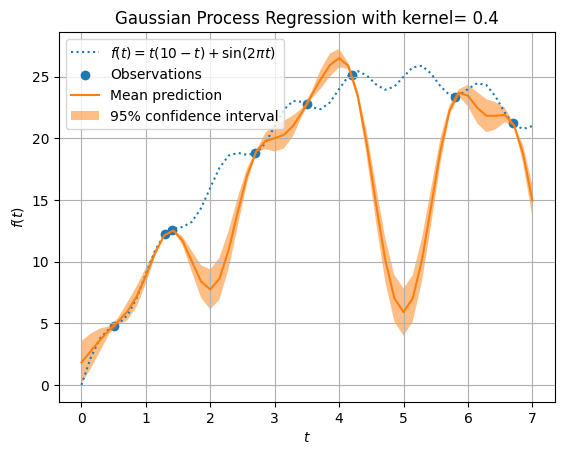

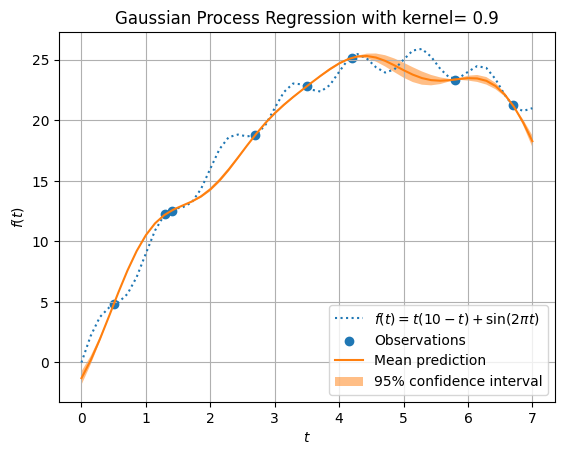

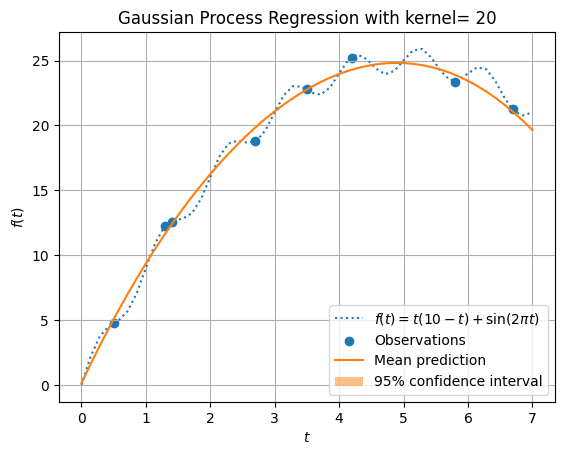

In [18]:
#Valores del kernel
parameter_vals = [0.4, 0.9, 20]

#Genera los valores temporales
t_values = linspace_time(TIME_VAL_MIN, TIME_VAL_MAX)

#Genera los observables
observables = generate_obs(PREDICTORS)

#Para cada Kernel genera una grafica
for L in parameter_vals:

    #Calcula la media y std
    mean, std = gaus_proc_regressor(t_values, PREDICTORS, observables, L)

    #Genera la grafica
    _ = plot_pred(t_values, PREDICTORS, observables, mean, std, L)

## Discusión

Para mostrar el efecto que tiene el hiperparametro L en la regresion Gaussiana, se realizaron 3 graficas con valor de L distinto. 

- Para un L muy bajo, en este caso $L = 0.4$ se puede ver como la prediccion si pasa por los observables, pero presenta un comportamiento muy lejano a la funcion real, dando como resultado una funcion con una forma muy compleja. Esto es el efecto creado por el overfitting, donde la regresion esta mas centrada en pasar exactamente por cada punto que en aproximar una funcion que prediga el comportamiento de los observables.

- Para un L muy alto, como en la grafica con $L = 20 $, se puede ver que la prediccion no se molesta en pasar por todos los observables, sino por una zona cercana a estos. El problema es que para un L tan grande, la prediccion ignora pequenas variaciones en la funcion, perdiendo informacion en el proceso.

- En la grafica restante se eligio un valor para $L = 0.9$, donde se muestra un comportamiento intermedio entre los dos casos explicados anteriormente. Se puede ver en la grafica como la funcion intenta seguir la tendencia de los observables y tambien intenta replicar las pequenas variaciones, con sus limitaciones (como la escasa cantidad de observables).